In [1]:
import pandas as pd


mbc = pd.read_csv('tmp/test.csv', usecols=range(5), index_col=False)
mbc = mbc.fillna('')

mbc

,Document,Speaker,ID,Phrases,Fragment
0,mbc001,Hemana Waaka,mbc001.6.0.1995-04-06,e.ngā matawaka/o.te motu,E ngā matawaka/o te motu
1,mbc001,Hemana Waaka,mbc001.6.1.1995-04-06,kia ora/* koutou,kia ora anō rā/koutou katoa.
2,mbc001,Hemana Waaka,mbc001.6.2.1995-04-06,* anei/ā tātou wehenga/mō tēnei ata,Anei rā/ā tātou wehenga kōrero/mō tēnei ata.
3,mbc001,Hemana Waaka,mbc001.8.0.1995-04-06,* mai/i.te tīmatanga/o.te kuhu/o.te rōpū/o pōh...,Mai/i te tīmatanga/o te kuhu atu/o Te Rōpū/o P...
4,mbc001,Hemana Waaka,mbc001.8.1.1995-04-06,* tērā anō/* ētahi āwangawanga/a.ngā kaumātua/...,tērā anō/ētahi āwangawanga/a ngā kaumātua rā/i...
...,...,...,...,...,...
192335,mbc273,Wena Tait,mbc273.128.15.1995-10-17,* whitu,whitu
192336,mbc273,Wena Tait,mbc273.128.16.1995-10-17,* rima,rima.
192337,mbc273,Wena Tait,mbc273.128.17.1995-10-17,nō reira,Nō reira
192338,mbc273,Wena Tait,mbc273.128.18.1995-10-17,ko wena/* tēnei/e mihi,ko Wena [Tait]/tēnei/e mihi atu nei


In [2]:
def dataset(col: str):
    df = pd.DataFrame(mbc[['ID', col, 'Fragment']])
    df['Observations'] = df[col].str.split('/')
    return df


dataset('Phrases')

,ID,Phrases,Fragment,Observations
0,mbc001.6.0.1995-04-06,e.ngā matawaka/o.te motu,E ngā matawaka/o te motu,"[e.ngā matawaka, o.te motu]"
1,mbc001.6.1.1995-04-06,kia ora/* koutou,kia ora anō rā/koutou katoa.,"[kia ora, * koutou]"
2,mbc001.6.2.1995-04-06,* anei/ā tātou wehenga/mō tēnei ata,Anei rā/ā tātou wehenga kōrero/mō tēnei ata.,"[* anei, ā tātou wehenga, mō tēnei ata]"
3,mbc001.8.0.1995-04-06,* mai/i.te tīmatanga/o.te kuhu/o.te rōpū/o pōh...,Mai/i te tīmatanga/o te kuhu atu/o Te Rōpū/o P...,"[* mai, i.te tīmatanga, o.te kuhu, o.te rōpū, ..."
4,mbc001.8.1.1995-04-06,* tērā anō/* ētahi āwangawanga/a.ngā kaumātua/...,tērā anō/ētahi āwangawanga/a ngā kaumātua rā/i...,"[* tērā anō, * ētahi āwangawanga, a.ngā kaumāt..."
...,...,...,...,...
192335,mbc273.128.15.1995-10-17,* whitu,whitu,[* whitu]
192336,mbc273.128.16.1995-10-17,* rima,rima.,[* rima]
192337,mbc273.128.17.1995-10-17,nō reira,Nō reira,[nō reira]
192338,mbc273.128.18.1995-10-17,ko wena/* tēnei/e mihi,ko Wena [Tait]/tēnei/e mihi atu nei,"[ko wena, * tēnei, e mihi]"


In [5]:
def marker(p: str):
    m, *_ = p.split()
    if m == '*':
        return ''
    
    return m


def bases(p: str):
    _, *b = p.split()
    if not b:
        return ''
    
    return b


phrases = dataset('Phrases')['Observations']

mbc['Particles'] = phrases.apply(lambda x: '/'.join(marker(p) for p in x))
mbc['Bases'] = phrases.apply(lambda x: '/'.join(b for p in x for b in bases(p)))

mbc

,Document,Speaker,ID,Phrases,Fragment,Particles,Bases
0,mbc001,Hemana Waaka,mbc001.6.0.1995-04-06,e.ngā matawaka/o.te motu,E ngā matawaka/o te motu,e.ngā/o.te,matawaka/motu
1,mbc001,Hemana Waaka,mbc001.6.1.1995-04-06,kia ora/* koutou,kia ora anō rā/koutou katoa.,kia/,ora/koutou
2,mbc001,Hemana Waaka,mbc001.6.2.1995-04-06,* anei/ā tātou wehenga/mō tēnei ata,Anei rā/ā tātou wehenga kōrero/mō tēnei ata.,/ā/mō,anei/tātou/wehenga/tēnei/ata
3,mbc001,Hemana Waaka,mbc001.8.0.1995-04-06,* mai/i.te tīmatanga/o.te kuhu/o.te rōpū/o pōh...,Mai/i te tīmatanga/o te kuhu atu/o Te Rōpū/o P...,/i.te/o.te/o.te/o/ki.te/i,mai/tīmatanga/kuhu/rōpū/pōhutu/marae/whakarewa...
4,mbc001,Hemana Waaka,mbc001.8.1.1995-04-06,* tērā anō/* ētahi āwangawanga/a.ngā kaumātua/...,tērā anō/ētahi āwangawanga/a ngā kaumātua rā/i...,//a.ngā/i,tērā/anō/ētahi/āwangawanga/kaumātua/roto-rua
...,...,...,...,...,...,...,...
192335,mbc273,Wena Tait,mbc273.128.15.1995-10-17,* whitu,whitu,,whitu
192336,mbc273,Wena Tait,mbc273.128.16.1995-10-17,* rima,rima.,,rima
192337,mbc273,Wena Tait,mbc273.128.17.1995-10-17,nō reira,Nō reira,nō,reira
192338,mbc273,Wena Tait,mbc273.128.18.1995-10-17,ko wena/* tēnei/e mihi,ko Wena [Tait]/tēnei/e mihi atu nei,ko//e,wena/tēnei/mihi


In [6]:
import numpy as np


def count(df):
    conditions: dict[str, pd.Series] = {
        None: pd.Series(np.concatenate(df['Observations'])),
        0: df['Observations'].str[0],
        1: df['Observations'].str[1]
    } 

    counts = {
        k: conditions[k].groupby(conditions[k]).count()
        for k in conditions
    }

    counts = pd.DataFrame.from_dict(counts)
    
    totals = counts[np.nan]
    counts = counts.drop(columns=[np.nan])
    
    counts[None] = totals - counts.sum(axis=1)
    
    return counts


df = dataset('Particles')
count(df)

,0.0,1.0,NaN
,56827.0,21688.0,8321.0
a,1045.0,2379.0,2555.0
a.aku,NaN,2.0,1.0
a.ana,NaN,1.0,2.0
a.aua,1.0,1.0,6.0
...,...,...,...
ō.ngā,1.0,1.0,4.0
ō.taua,NaN,1.0,1.0
ō.te,1.0,1.0,1.0
ō.tō,NaN,NaN,1.0


In [7]:
import matplotlib.pyplot as plt


def log_odds(counts) -> pd.DataFrame:
    p = counts.div(counts.sum(axis=1), axis=0)
    odds = p / (1 - p)
    return np.log(odds)


df = dataset('Particles')
counts = count(df)

particle_odds = log_odds(counts).replace(np.inf, np.nan).replace(-np.inf, np.nan).dropna()
particle_odds

/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,0.0,1.0,NaN
,0.638514,-1.099902,-2.244507
a,-1.552133,-0.414254,-0.292757
a.aua,-1.945910,-1.945910,1.098612
a.ngā,-2.299007,-1.192013,0.734974
a.taku,-1.041454,-0.441833,-0.628609
...,...,...,...
ā.tō,0.847298,-2.751535,-1.152680
ō,0.004301,-0.741937,-1.541316
ō.aua,-0.693147,-0.693147,-0.693147
ō.ngā,-1.609438,-1.609438,0.693147


The mean log odds of a given type appearing in offset 1 are negative, while the other two classes show bimodal behaviour, with a positive and negative peak. This corresponds to the intuition that offset 1 is "unmarked" in a Māori utterance. Given any type, it either marks offset 0 or "other". We correspond these classes to the intuitive categories of "predicate" and "modifier".

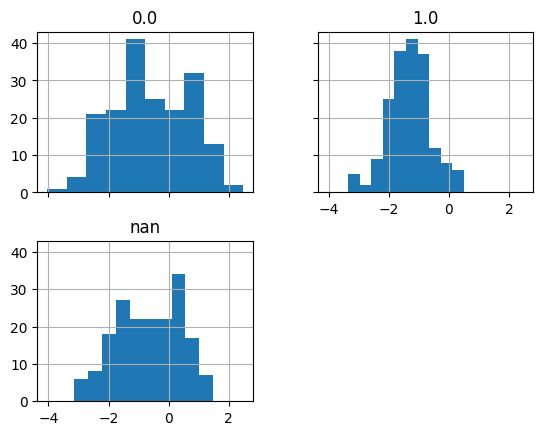

In [8]:
particle_odds.hist(sharex=True, sharey=True)
plt.show()

There is a moderate negative correlation between the log odds of a token appearing in predicate or modifier position. Support for a third class is given by the presence of tokens with negative log odds for both classes. However, representation in the top-right quadrant is not possible, as the two classes are at most complementary.

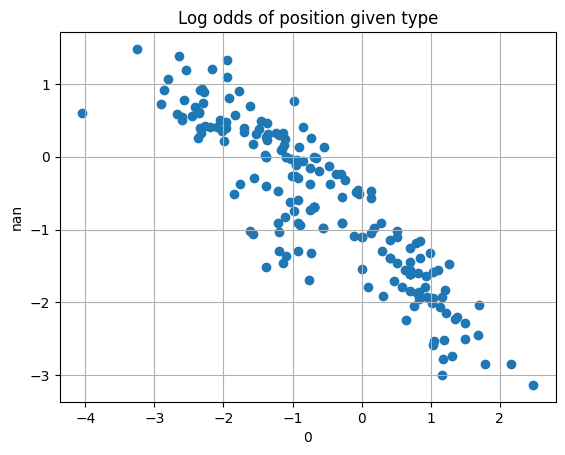

In [9]:
plt.scatter(particle_odds[0], particle_odds[np.nan])
plt.title('Log odds of position given type')
plt.xlabel(0)
plt.ylabel(np.nan)
plt.grid()

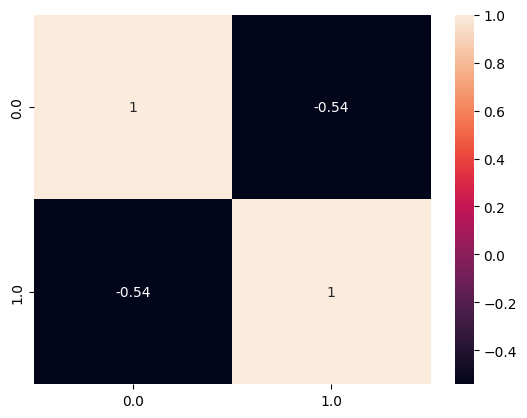

In [10]:
import seaborn as sns


sns.heatmap(particle_odds.drop(columns=[np.nan]).corr(), annot=True)
plt.show()

No such bimodal distribution exists over the bases. However, we are much more likely to identify predicating or modifying types than observe any that are committed to offset 1.

/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,0.0,1.0,NaN
count,3093.000000,3093.000000,3093.000000
mean,-0.566540,-1.226449,-0.602122
std,0.940231,0.735687,0.859760
min,-4.189655,-7.297768,-6.197801
25%,-1.098612,-1.609438,-1.098612
50%,-0.639080,-1.163151,-0.567984
75%,0.000000,-0.708759,0.000000
max,5.909441,1.871802,2.302585


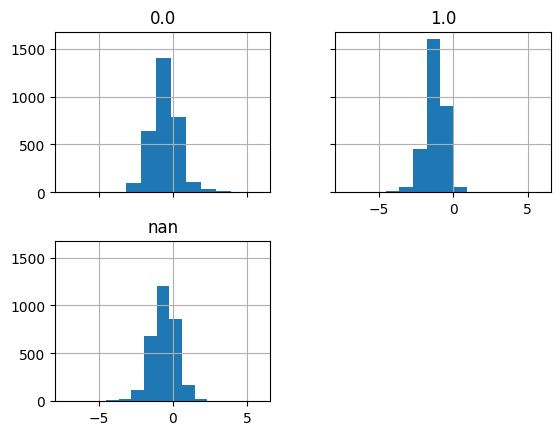

In [11]:
df = dataset('Bases')
counts = count(df)
base_odds = log_odds(counts).replace(np.inf, np.nan).replace(-np.inf, np.nan).dropna()

display(base_odds.describe())
base_odds.hist(sharex=True, sharey=True)
plt.show()

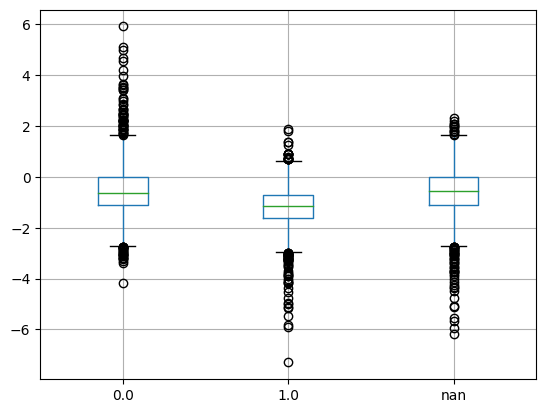

In [12]:
base_odds.boxplot()
plt.show()

We label a phrase "predicate" if its marker has positive odds for offset 0. Otherwise, if it has positive log odds for unknown, it is labelled "modifier". We independently label a phrase "verb" if its *base* has positive odds for offset 0. Default identification is "topic-noun".

In [513]:
class Annotator:
    def __init__(self, markers: pd.DataFrame, bases: pd.DataFrame):
        self.markers = log_odds(markers)
        self.bases = log_odds(bases)

    def is_predicate(self, marker):
        return self.markers[0][marker] > 0
    
    def is_modifier(self, marker):
        return self.markers[np.nan][marker] > 0
    
    def is_verb(self, base):
        return self.bases[0][base] > 0
    
    def classify(self, marker, *bases):
        if bases:
            base = bases[-1]
            verb = 'V' if self.is_verb(base) else 'N'
        else:
            verb = ''

        if self.is_predicate(marker):
            return 'pred' + verb
        elif self.is_modifier(marker):
            return 'mod' + verb
        
        return 'top' + verb
    
    def label(self, phrase: str):
        words = phrase.split(' ')
        marker, *bases = words
        if marker == '*':
            marker = ''
        
        try:
            return self.classify(marker, *bases)
        except KeyError:
            display(phrase)
            raise
    

annotator = Annotator(*[count(dataset(col)) for col in ['Particles', 'Bases']])
phrases = [
    '* ētahi āwangawanga'
]

[annotator.label(p) for p in phrases]

/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/Users/connortaylorbrown/Desktop/linguistics/masters/thesis/mbc-analyser/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


['predN']

In [514]:
phrases = dataset('Phrases')

phrases['Labelled'] = phrases['Observations'].apply(lambda x: [annotator.label(p) for p in x])

phrases

,ID,Phrases,Fragment,Observations,Labelled
0,mbc001.6.0.1995-04-06,e.ngā matawaka/o.te motu,E ngā matawaka o te motu,"[e.ngā matawaka, o.te motu]","[topV, modN]"
1,mbc001.6.1.1995-04-06,kia ora/* koutou,kia ora anō rā koutou katoa.,"[kia ora, * koutou]","[predV, predN]"
2,mbc001.6.2.1995-04-06,* anei/ā tātou wehenga/mō tēnei ata,Anei rā ā tātou wehenga kōrero mō tēnei ata.,"[* anei, ā tātou wehenga, mō tēnei ata]","[predV, predN, modN]"
3,mbc001.8.0.1995-04-06,* mai/i.te tīmatanga/o.te kuhu/o.te rōpū/o pōh...,Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...,"[* mai, i.te tīmatanga, o.te kuhu, o.te rōpū, ...","[predV, modN, modN, modN, modN, modN, topN]"
4,mbc001.8.1.1995-04-06,* tērā anō/* ētahi āwangawanga/a.ngā kaumātua/...,tērā anō ētahi āwangawanga a ngā kaumātua rā i...,"[* tērā anō, * ētahi āwangawanga, a.ngā kaumāt...","[predN, predN, modN, topN]"
...,...,...,...,...,...
192314,mbc273.128.15.1995-10-17,* whitu,whitu,[* whitu],[predV]
192315,mbc273.128.16.1995-10-17,* rima,rima.,[* rima],[predN]
192316,mbc273.128.17.1995-10-17,nō reira,Nō reira,[nō reira],[predV]
192317,mbc273.128.18.1995-10-17,ko wena/* tēnei/e mihi,ko Wena [Tait] tēnei e mihi atu nei,"[ko wena, * tēnei, e mihi]","[predV, predN, topV]"


In [515]:
aligned = pd.Series(zip(dataset('Particles')['Observations'], phrases['Labelled']))
paired = aligned.apply(lambda x: list(zip(*x)))

labelled = pd.DataFrame(np.concatenate(paired), columns=['Marker', 'Label'])
labelled['Count'] = 1

labelled

,Marker,Label,Count
0,e.ngā,topV,1
1,o.te,modN,1
2,kia,predV,1
3,,predN,1
4,,predV,1
...,...,...,...
431324,,predN,1
431325,e,topV,1
431326,e,topN,1
431327,i,topN,1


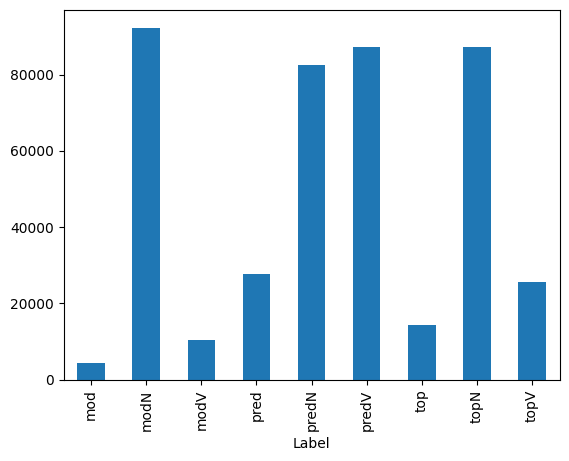

In [516]:
labelled.groupby('Label').count()['Marker'].plot.bar()
plt.show()

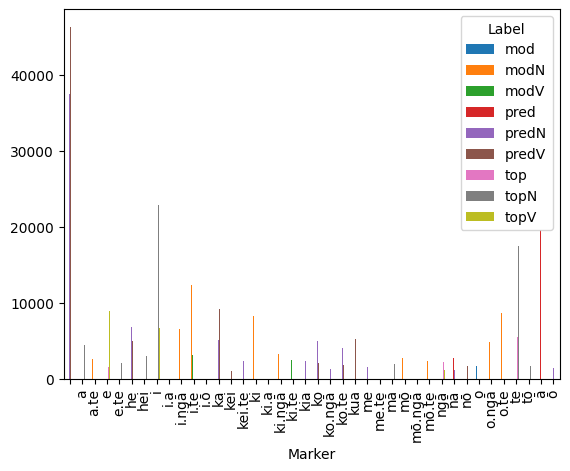

In [517]:
pivot = labelled.pivot_table(index='Marker', columns='Label', values='Count', aggfunc='sum')
pivot[pivot > 1000].dropna(how='all').plot.bar()
plt.show()

A larger number of types mark nouns in all positions. This is very likely an effect of particle concatenation. However, modifier noun marking is especially strong. Given a topic noun marker, odds are at least even that the qualification (noun) is correct.

Label,mod,modN,modV,pred,predN,predV,top,topN,topV
count,7.000000,51.000000,51.000000,15.000000,72.000000,72.000000,22.000000,52.000000,51.000000
mean,-5.752746,2.778177,-2.864818,-2.138095,1.044929,-1.274612,-2.675297,1.685841,-1.957262
std,3.824852,0.855915,0.772239,1.744143,1.374809,1.331939,1.339487,1.126954,1.028238
min,-9.652202,1.029188,-4.859812,-5.503470,-2.407726,-4.893399,-5.455321,-0.323903,-4.844187
25%,-8.680955,2.053674,-3.508064,-2.974810,0.000000,-2.079442,-3.731316,0.845250,-2.574473
50%,-8.148156,2.908721,-2.932674,-2.494595,0.938851,-1.122493,-2.511503,1.592487,-1.933590
75%,-1.788080,3.508064,-2.384750,-1.964104,1.928628,-0.136741,-1.795997,2.436059,-1.279296
max,-1.530792,4.859812,-1.383244,2.313323,4.127134,1.098612,-0.371176,4.844187,0.000000


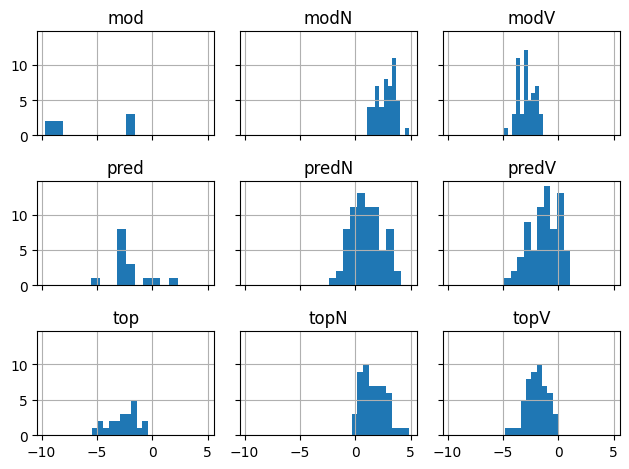

In [518]:
marker_label_odds = log_odds(pivot).replace(np.inf, np.nan).dropna(how='all')

display(marker_label_odds.describe())
marker_label_odds.hist(sharex=True, sharey=True)
plt.tight_layout()

In [519]:
marker_label_odds.T['i']

Label
mod           NaN
modN          NaN
modV          NaN
pred          NaN
predN         NaN
predV         NaN
top     -2.326584
topN     0.866761
topV    -1.343204
Name: i, dtype: float64

In [520]:
aligned = pd.Series(zip(phrases['Observations'], phrases['Labelled']))
paired = aligned.apply(lambda x: list(zip(*x)))

mapped = pd.DataFrame(np.concatenate(paired), columns=['Phrase', 'Label'])
mapped['Count'] = 1

mapped

,Phrase,Label,Count
0,e.ngā matawaka,topV,1
1,o.te motu,modN,1
2,kia ora,predV,1
3,* koutou,predN,1
4,* anei,predV,1
...,...,...,...
431324,* tēnei,predN,1
431325,e mihi,topV,1
431326,e tuku,topN,1
431327,i tēnei wāhanga,topN,1


In [521]:
mapped['Base'] = mapped['Phrase'].str.split(' ').apply(lambda x: x[-1])

base_pivot = mapped.pivot_table(index='Base', columns='Label', values='Count', aggfunc='sum')

base_label_odds = log_odds(base_pivot).replace(np.inf, np.nan).dropna(how='all')

base_label_odds

Label,mod,modN,modV,pred,predN,predV,top,topN,topV
Base,,,,,,,,,
,NaN,NaN,-1.098612,NaN,NaN,0.000000,NaN,NaN,-1.098612
'kauae',NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
a,NaN,NaN,NaN,NaN,-4.960044,NaN,4.366631,-5.184589,NaN
aaron,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
act,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
ūkura,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
ūmanga,NaN,0.510826,NaN,NaN,-0.510826,NaN,NaN,NaN,NaN
ūmere,NaN,NaN,-2.079442,NaN,NaN,1.252763,NaN,NaN,-2.079442


### Take 2

In [13]:
def split(x: str):
    marker, *bases = x['Phrase'].split(' ')
    return marker if marker != '*' else '', bases[-1] if bases else ''


df = dataset('Phrases')
phrases = pd.DataFrame(np.concatenate(df['Observations']), columns=['Phrase'])
phrases[['Marker', 'Base']] = phrases.apply(split, axis=1, result_type='expand')

lengths = df['Observations'].str.len()

display(lengths)
phrases

0         2
1         2
2         3
3         7
4         4
         ..
192335    1
192336    1
192337    1
192338    3
192339    3
Name: Observations, Length: 192340, dtype: int64

,Phrase,Marker,Base
0,e.ngā matawaka,e.ngā,matawaka
1,o.te motu,o.te,motu
2,kia ora,kia,ora
3,* koutou,,koutou
4,* anei,,anei
...,...,...,...
431425,* tēnei,,tēnei
431426,e mihi,e,mihi
431427,e tuku,e,tuku
431428,i tēnei wāhanga,i,wāhanga


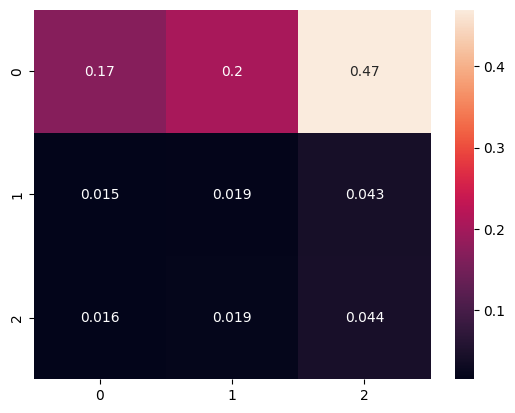

In [14]:
def p(df: pd.DataFrame):
    return df.div(df.sum(axis=1), axis=0)


df = dataset('Bases')
counts = count(df)
p_bases = p(counts)

df = dataset('Particles')
counts = count(df)
p_markers = p(counts)

def conjunction(marker, base):
    return np.outer(p_markers.T[marker], p_bases.T[base])


sns.heatmap(conjunction('nā', 'tauiwi'), annot=True)
plt.show()

In [15]:
import os
import pathlib


def save_p(label, df):
    dir = pathlib.Path('tmp', label)
    os.makedirs(dir, exist_ok=True)
    np.save(pathlib.Path(dir, 'index.npy'), df.index.values)
    np.save(pathlib.Path(dir, 'p.npy'), df)


save_p('markers', p_markers)
save_p('bases', p_bases)
np.load('tmp/markers/index.npy', allow_pickle=True)

array(['', 'a', 'a.aku', 'a.ana', 'a.aua', 'a.ngā', 'a.taku', 'a.tana',
       'a.taua', 'a.te', 'a.tā', 'a.tō', 'a.wā', 'a.wō', 'a.ā', 'a.ō',
       'aku', 'ana', 'aua', 'e', 'e.aku', 'e.ana', 'e.aua', 'e.ngā',
       'e.taku', 'e.tana', 'e.taua', 'e.te', 'e.tā', 'e.tō', 'e.wā',
       'e.wō', 'e.ā', 'e.ō', 'he', 'he.ana', 'he.ngā', 'he.taua', 'he.te',
       'he.tō', 'he.wā', 'hei', 'hei.a', 'hei.a.te', 'hei.aku', 'hei.ngā',
       'hei.o', 'hei.taua', 'hei.te', 'hei.tā', 'hei.tā.ngā',
       'hei.tā.taua', 'hei.tā.te', 'hei.tō', 'hei.wā', 'hei.ā',
       'hei.ā.tō', 'hei.ō', 'i', 'i.a', 'i.a.ngā', 'i.a.taua', 'i.a.te',
       'i.a.tā', 'i.a.tō', 'i.a.ō', 'i.aku', 'i.ana', 'i.aua', 'i.ngā',
       'i.o', 'i.o.wā', 'i.taku', 'i.tana', 'i.taua', 'i.te', 'i.tā',
       'i.tā.ngā', 'i.tā.te', 'i.tō', 'i.tō.taua', 'i.tō.te', 'i.wā',
       'i.wā.ngā', 'i.wō', 'i.ā', 'i.ō', 'i.ō.ngā', 'i.ō.te', 'ka',
       'ka.aua', 'ka.ngā', 'ka.te', 'ka.tā', 'ka.tā.te', 'ka.tō', 'kei',
       'kei.a', '

In [524]:
phrases['Matrix'] = phrases.apply(lambda x: conjunction(x['Marker'], x['Base']), axis=1)

phrases

,Phrase,Marker,Base,Matrix
0,e.ngā matawaka,e.ngā,matawaka,"[[0.23359369297028978, 0.06256973918847047, 0...."
1,o.te motu,o.te,motu,"[[0.005786736288982104, 0.025708287447772954, ..."
2,kia ora,kia,ora,"[[0.523232962530583, 0.04448391737193806, 0.05..."
3,* koutou,,koutou,"[[0.08327533881437979, 0.33810100036457386, 0...."
4,* anei,,anei,"[[0.6267593367100088, 0.006840483893151528, 0...."
...,...,...,...,...
431324,* tēnei,,tēnei,"[[0.13260357251319405, 0.20673676975821734, 0...."
431325,e mihi,e,mihi,"[[0.18738724491551012, 0.0841598854357379, 0.0..."
431326,e tuku,e,tuku,"[[0.11747718561967989, 0.06387821968070094, 0...."
431327,i tēnei wāhanga,i,wāhanga,"[[0.0685302824952867, 0.09233892524012809, 0.1..."


In [525]:
phrases['Labelled'] = phrases['Matrix'].apply(lambda a: np.unravel_index(np.nanargmax(a, axis=None), a.shape))

phrases

,Phrase,Marker,Base,Matrix,Labelled
0,e.ngā matawaka,e.ngā,matawaka,"[[0.23359369297028978, 0.06256973918847047, 0....","(0, 0)"
1,o.te motu,o.te,motu,"[[0.005786736288982104, 0.025708287447772954, ...","(2, 2)"
2,kia ora,kia,ora,"[[0.523232962530583, 0.04448391737193806, 0.05...","(0, 0)"
3,* koutou,,koutou,"[[0.08327533881437979, 0.33810100036457386, 0....","(0, 1)"
4,* anei,,anei,"[[0.6267593367100088, 0.006840483893151528, 0....","(0, 0)"
...,...,...,...,...,...
431324,* tēnei,,tēnei,"[[0.13260357251319405, 0.20673676975821734, 0....","(0, 2)"
431325,e mihi,e,mihi,"[[0.18738724491551012, 0.0841598854357379, 0.0...","(2, 0)"
431326,e tuku,e,tuku,"[[0.11747718561967989, 0.06387821968070094, 0....","(2, 2)"
431327,i tēnei wāhanga,i,wāhanga,"[[0.0685302824952867, 0.09233892524012809, 0.1...","(2, 2)"


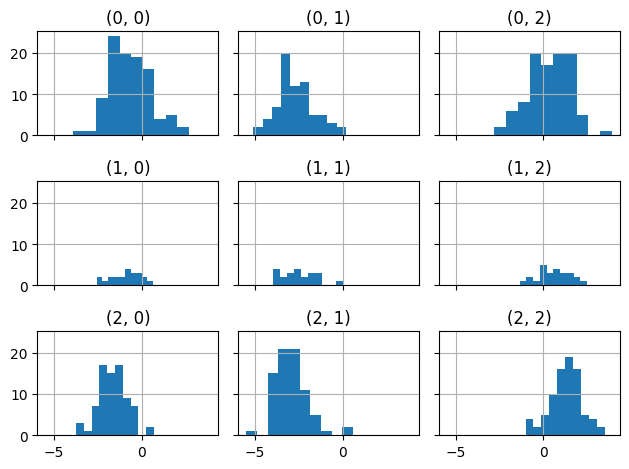

In [526]:
marker_classifier = phrases.pivot_table(index='Marker', columns='Labelled', aggfunc='count', values='Matrix')

log_odds(marker_classifier).replace(np.inf, np.nan).dropna(how='all').hist(sharex=True, sharey=True)
plt.tight_layout()

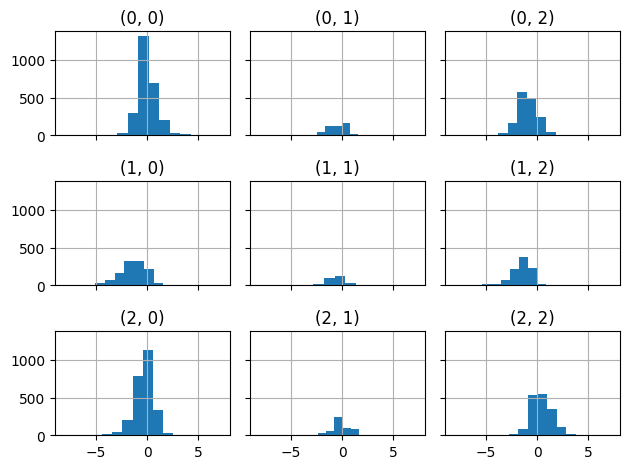

In [527]:
base_classifier = phrases.pivot_table(index='Base', columns='Labelled', aggfunc='count', values='Matrix')

log_odds(base_classifier).replace(np.inf, np.nan).dropna(how='all').hist(sharex=True, sharey=True)
plt.tight_layout()

In [532]:
cursor = pd.DataFrame(lengths)

cursor['End'] = cursor['Observations'].cumsum()
cursor['Offset'] = cursor['End'] - cursor['Observations']

def join_utterances(df: pd.DataFrame):
    for _, row in cursor.iterrows():
        offset, end = row['Offset'], row['End']
        yield (df['Labelled'][offset:end]).array


labelled = pd.DataFrame(join_utterances(phrases))
utterances = dataset('Phrases')
utterances[labelled.columns] = labelled

utterances

,ID,Phrases,Fragment,Observations,0,1,2,3,4,5,...,9,10,11,12,13,14,15,16,17,18
0,mbc001.6.0.1995-04-06,e.ngā matawaka/o.te motu,E ngā matawaka o te motu,"[e.ngā matawaka, o.te motu]","(0, 0)","(2, 2)",None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,mbc001.6.1.1995-04-06,kia ora/* koutou,kia ora anō rā koutou katoa.,"[kia ora, * koutou]","(0, 0)","(0, 1)",None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,mbc001.6.2.1995-04-06,* anei/ā tātou wehenga/mō tēnei ata,Anei rā ā tātou wehenga kōrero mō tēnei ata.,"[* anei, ā tātou wehenga, mō tēnei ata]","(0, 0)","(0, 2)","(2, 2)",None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,mbc001.8.0.1995-04-06,* mai/i.te tīmatanga/o.te kuhu/o.te rōpū/o pōh...,Mai i te tīmatanga o te kuhu atu o Te Rōpū o P...,"[* mai, i.te tīmatanga, o.te kuhu, o.te rōpū, ...","(0, 0)","(2, 0)","(2, 0)","(2, 2)","(2, 2)","(2, 2)",...,None,None,None,None,None,None,None,None,None,None
4,mbc001.8.1.1995-04-06,* tērā anō/* ētahi āwangawanga/a.ngā kaumātua/...,tērā anō ētahi āwangawanga a ngā kaumātua rā i...,"[* tērā anō, * ētahi āwangawanga, a.ngā kaumāt...","(0, 1)","(0, 0)","(2, 2)","(2, 2)",None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192314,mbc273.128.15.1995-10-17,* whitu,whitu,[* whitu],"(0, 0)",None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
192315,mbc273.128.16.1995-10-17,* rima,rima.,[* rima],"(0, 0)",None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
192316,mbc273.128.17.1995-10-17,nō reira,Nō reira,[nō reira],"(0, 0)",None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
192317,mbc273.128.18.1995-10-17,ko wena/* tēnei/e mihi,ko Wena [Tait] tēnei e mihi atu nei,"[ko wena, * tēnei, e mihi]","(0, 0)","(0, 2)","(2, 0)",None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [536]:
utterances[utterances['Phrases'].str.startswith('nā') & utterances['Phrases'].str.contains('/i')]

,ID,Phrases,Fragment,Observations,0,1,2,3,4,5,...,9,10,11,12,13,14,15,16,17,18
162,mbc001.29.0.1995-04-07,nā.te kore/o.ngā pirihimana/me.ngā iwi/o whang...,Nā te kore o ngā pirihimana me ngā iwi o Whang...,"[nā.te kore, o.ngā pirihimana, me.ngā iwi, o w...","(0, 0)","(2, 2)","(2, 2)","(2, 2)","(2, 0)","(2, 2)",...,"(2, 2)","(2, 0)","(2, 2)",None,None,None,None,None,None,None
235,mbc001.38.18.1995-04-08,nā reira/e kī/te alliance/ko.ngā mahi/a.te kāw...,Nā reira e kī ana te [Alliance] ko ngā mahi a ...,"[nā reira, e kī, te alliance, ko.ngā mahi, a.t...","(0, 0)","(2, 0)","(1, 2)","(0, 2)","(2, 2)","(2, 2)",...,None,None,None,None,None,None,None,None,None,None
282,mbc001.40.45.1995-04-08,nā reira/e.te iwi/kei wareware/* tātou/a.te pō...,Nā reira e te iwi kei wareware rā tātou a te p...,"[nā reira, e.te iwi, kei wareware, * tātou, a....","(0, 0)","(2, 2)","(0, 1)","(0, 1)","(2, 2)","(0, 0)",...,"(0, 0)","(0, 2)",None,None,None,None,None,None,None,None
583,mbc002.23.89.1995-04-24,nā reira/i runga/i tērā kaupapa/me kī,nā reira i runga i tērā kaupapa me kī pēnei pea,"[nā reira, i runga, i tērā kaupapa, me kī]","(0, 0)","(2, 2)","(2, 2)","(0, 0)",None,None,...,None,None,None,None,None,None,None,None,None,None
753,mbc003.11.11.1995-05-06,nā/ko.tō ku mōhio/* tēnei/i tēnei wā,nā ko tōku mōhio noa iho tēnei i tēnei wā,"[nā, ko.tō ku mōhio, * tēnei, i tēnei wā]","(0, 0)","(0, 0)","(0, 2)","(2, 2)",None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190873,mbc272.202.4.1995-08-01,nā runga/i.te mahi/i ako/* au,nā runga i te mahi i ako ai au,"[nā runga, i.te mahi, i ako, * au]","(0, 2)","(2, 2)","(2, 2)","(0, 1)",None,None,...,None,None,None,None,None,None,None,None,None,None
191261,mbc273.6.17.1995-08-29,nā/ko.te aho/o.tā tātou kaupapa/i tēnei rā,Nā ko te aho tāhuhu o tā tātou kaupapa i tēnei rā,"[nā, ko.te aho, o.tā tātou kaupapa, i tēnei rā]","(0, 0)","(0, 2)","(2, 2)","(2, 2)",None,None,...,None,None,None,None,None,None,None,None,None,None
191570,mbc273.37.152.1995-08-29,nā runga/i tēnā,Nā runga i tēnā,"[nā runga, i tēnā]","(0, 2)","(2, 0)",None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
191607,mbc273.41.14.1995-08-29,nā/i.te wiki/i roto/i.te kai/a.te rangatira,Nā i te wiki hou i roto i Te Kai a te Rangatira,"[nā, i.te wiki, i roto, i.te kai, a.te rangatira]","(0, 0)","(2, 2)","(2, 2)","(2, 2)","(2, 2)",None,...,None,None,None,None,None,None,None,None,None,None
